# 📘 Notebook: H₂ Dimer Potential Energy Scan with CQED-DFT

🧠 Overview

This example demonstrates how to compute an intermolecular potential energy curve for an $H_2$ dimer using:

Density Functional Theory (DFT)
Cavity Quantum Electrodynamics (QED)
Dispersion-corrected functional (wB97X-D)

We scan the separation between two $H_2$ molecules and observe how the energy changes in the presence of a cavity field.

In [1]:
import numpy as np
import psi4
import matplotlib.pyplot as plt

from cqed_rhf.calculator import CQEDRHFCalculator

## 🖥️ Psi4 Configuration

We configure memory, threading, and SCF options.

In [2]:
psi4.set_memory("2 GB")
psi4.set_num_threads(2)

psi4_options = {
    "basis": "cc-pVDZ",
    "scf_type": "pk",
    "e_convergence": 1e-10,
    "d_convergence": 1e-10,
    "dft_radial_points": 99,
    "dft_spherical_points": 302,
    "dft_pruning_scheme": "none"
}
psi4.set_options(psi4_options)


  Memory set to   1.863 GiB by Python driver.
  Threads set to 2 by Python driver.


# 🔦 QED Parameters

We define the cavity coupling with field polarized along z-axis with coupling strength of 0.05 a.u.

In [ ]:
lambda_vector = np.array([0.0, 0.0, 0.05])
omega = 0.07349864501573

In [ ]:
print(f"Dispersion Energy: {energy_disp - energy_no_disp}")
print(f"Gradient: {grad_disp - grad_no_disp}")

## 📏 Scan Range

We vary the intermolecular separation:

In [3]:
d_vals = np.linspace(2.2, 6.0, 41)

## 🧮 CQED Calculator

We use $\omega$B97X-D, where the QED-SCF uses wB97X and the dispersion is added separately (handled by psi4)

In [ ]:
calc = CQEDRHFCalculator(
    lambda_vector=lambda_vector,
    psi4_options=psi4_options,
    omega=omega,
    density_fitting=True,
    functional="wb97x-d",
    debug=False,
)

# 🔁 Perform the Scan

For each separation $𝑑$, we build a geometry and compute the energy.

In [4]:
energies_dft = []
energies_ccsd = []
energies_fci = []
distances = []

for d in d_vals:

    geom = f"""
    0 1
    H  -0.370000000  0.000000000  0.000000000
    H   0.370000000  0.000000000  0.000000000
    H  -0.370000000  0.000000000  {d}
    H   0.370000000  0.000000000  {d}
    symmetry c1
    no_reorient
    nocom
    """
    mol = psi4.geometry(geom)

    print(f"Running d = {d:.3f}")
    E = psi4.energy("wb97x-d")
    #E = calc.energy(geom)

    energies_dft.append(E)
    E = psi4.energy("ccsd")
    energies_ccsd.append(E)
    E = psi4.energy("fci")
    energies_fci.append(E)
    distances.append(d)

distances = np.array(distances)
energies_dft = np.array(energies_dft)
energies_ccsd = np.array(energies_ccsd)
energies_fci = np.array(energies_fci)

Running d = 2.200

Scratch directory: /tmp/
   => Libint2 <=

    Primary   basis highest AM E, G, H:  6, 6, 3
    Auxiliary basis highest AM E, G, H:  7, 7, 4
    Onebody   basis highest AM E, G, H:  -, -, -
    Solid Harmonics ordering:            Gaussian

*** tstart() called on CHEM9QDFT72ALT
*** at Fri Apr  3 20:01:22 2026

   => Loading Basis Set <=

    Name: CC-PVDZ
    Role: ORBITAL
    Keyword: BASIS
    atoms 1-4 entry H          line    22 file /Users/jfoley19/miniconda3/envs/psi4_new/share/psi4/basis/cc-pvdz.gbs 

   => WB97X-D: Empirical Dispersion <=

    Chai and Head-Gordon Dispersion Correction
    Chai, J.-D.; Head-Gordon, M. (2010), J. Chem. Phys., 132: 6615-6620

        s6 =       1.000000


         ---------------------------------------------------------
                                   SCF
               by Justin Turney, Rob Parrish, Andy Simmonett
                          and Daniel G. A. Smith
                              RKS Reference
                 

# 💾 Save Data 
Strong recommendation that you update this block to save as a json file :)

In [ ]:
np.savetxt(
    "h2_dimer_scan_qed_dispersion_corrected.dat",
    np.column_stack([distances, energies]),
    header="d (Angstrom)    Energy (Hartree)"
)

In [ ]:
E_asymptote = energies_fci[-1]

# 📊 Plot the Potential Energy Curve

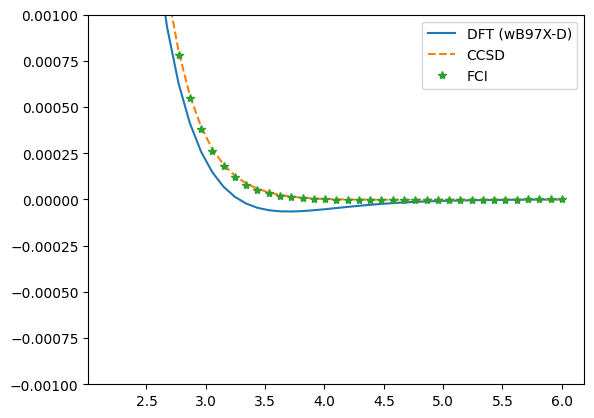

In [5]:
E_asymptote_fci  = energies_fci[-1]
E_asymptote_ccsd = energies_ccsd[-1]
E_asymptote_dft  = energies_dft[-1]

plt.plot(distances, energies_dft  - E_asymptote_dft,  "-",  label="DFT (wB97X-D)")
plt.plot(distances, energies_ccsd - E_asymptote_ccsd, "--", label="CCSD")
plt.plot(distances, energies_fci  - E_asymptote_fci,  "*",  label="FCI")
plt.ylim(-1e-3,1e-3)
plt.legend()
plt.show()